In [2]:
import sys
import os
sys.path.append(os.path.abspath("../clean_code/"))

In [2]:
from Visualization import generalVisualization
from Visualization import mnistVisuals
from Visualization import visualHelpers
from Utilities import config
import pickle
import select_landmarks_MI
import importlib
import voltagemap
import main
import matplotlib.pyplot as plt
import numpy as np

In [4]:
importlib.reload(generalVisualization)
importlib.reload(mnistVisuals)
importlib.reload(visualHelpers)
importlib.reload(voltagemap)
importlib.reload(main)

<module 'main' from '/Users/yoavfreund/projects/VoltageDimentionalReduction/clean_code/main.py'>

In [4]:
config.params['file_path']= '../../Voltage_Data/mnist/mnist.csv'
config.params['split_char']= ','
config.params['normalize_vecs']= False

config.params['max_centroids']= 1000
config.params['init_size']= 5000
config.params['batch_size']= 1000
config.params['kmeans_output']= '../../Voltage_Temp/Results/streaming_centroids.npy'
config.params['k']=2
config.params['r']=1

data_to_save = main.main()

Read 5000 vectors
Estimated max pairwise distance squared, FAISS) = 16295346.0000
 Estimated minimum distance squared = 89648.0000
10 vectors in index after adding initial centroid
Read 6000 vectors
number of centroids: 268, max_centroids: 1000
Read 7000 vectors
number of centroids: 416, max_centroids: 1000
Read 8000 vectors
number of centroids: 580, max_centroids: 1000
Read 9000 vectors
number of centroids: 717, max_centroids: 1000
Read 10000 vectors
number of centroids: 842, max_centroids: 1000
Read 11000 vectors
number of centroids: 958, max_centroids: 1000
Read 12000 vectors
number of centroids: 1000, max_centroids: 1000
Reached maximum number of centroids: 1000
Read 70000 vectorsmean d2= 2236043.416mean d2= 2133936.591125mean d2= 2015763.7764166666mean d2= 1933093.2019375mean d2= 1889360.8726mean d2= 1839981.4169583332mean d2= 1814723.1565mean d2= 1786934.92340625mean d2= 1765018.4252222222mean d2= 1755476.13365mean d2= 1739838.16125mean d2= 1723594.4673125mean d2= 1711137.1557692

In [5]:
data_to_save['voltage_map'] = select_landmarks_MI.select_landmarks(data_to_save['all_voltages'])

Adding landmark index=0 lm_index=200 with MI=0.5728
Adding landmark index=7 lm_index=633 with MI=1.0814
Adding landmark index=2 lm_index=927 with MI=1.5953
Adding landmark index=3 lm_index=88 with MI=2.0421
Adding landmark index=14 lm_index=823 with MI=2.4455
Adding landmark index=36 lm_index=103 with MI=2.8258
Adding landmark index=40 lm_index=592 with MI=3.1919
Adding landmark index=28 lm_index=567 with MI=3.4986
Adding landmark index=41 lm_index=990 with MI=3.8213
Adding landmark index=62 lm_index=897 with MI=4.0181


In [6]:
with open('../../Voltage_Temp/Results/saved_data.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)

In [7]:
with open('../../Voltage_Temp/Results/voltage_map.npy', 'rb') as f:
    data_to_save = pickle.load(f)

In [8]:
voltage_map = voltagemap.VoltageMap()
for entry in data_to_save['voltage_map'].entries:
    voltage_map.add_solution(entry["landmark"], np.log(entry["voltages"]))

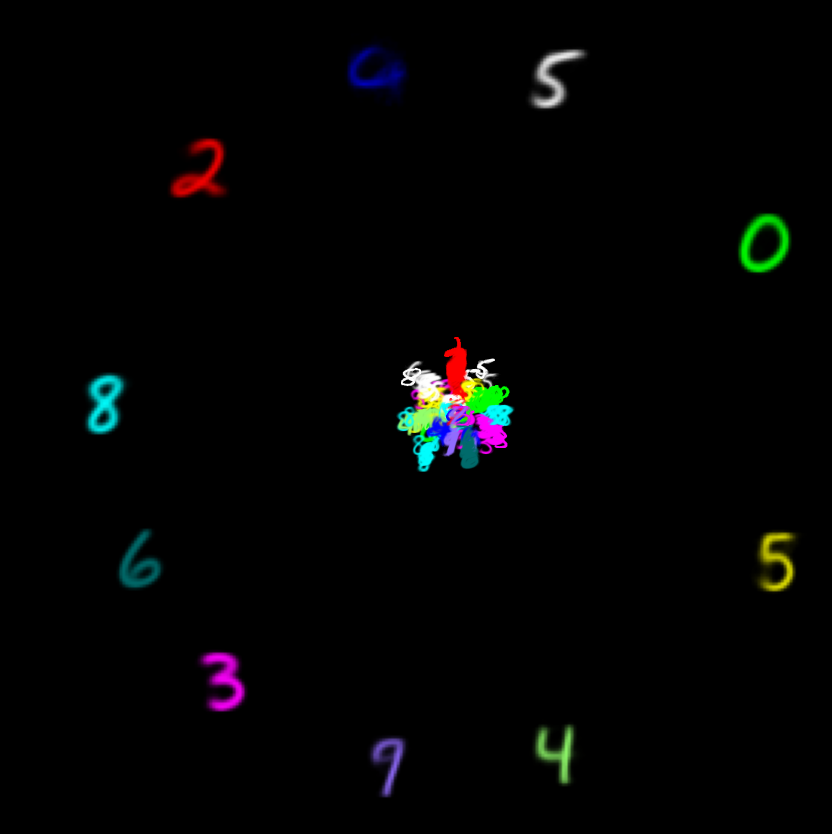

In [9]:
plot_mnist_unlabeled(data_to_save['voltage_map'], data_to_save['centroids'])

In [ ]:
def plot_mnist_digits(voltages, data, labels, transformation="mds", landmarkSize=3, alpha_actual=1, percent_size=0.02, out_file=None):
    """
    Draws the MNIST digits corresponding to each point after reducing the dimention to 2 by either PCA or MDS

    Args:
        selected_digits (List[int]): The digits to plot
        voltages (VoltageMap): The digits to plot
        data (SetOfPoints): The digits to plot
        correct (List[int]): The correct labels for each point in data
        n_outliers (Optional[int]): The number of outliers to remove
        alpha_actual (Optional[float]): The opacity of each digit, 1 is fully opaque and 0 is fully transparent
        percent_size (Optional[float]): The size of each digit, 1 is the size of the whole space and 0 is no image size
        out_file (Optional[str]): If provided, the output path to save the figure (e.g., "digits.png")
    """

    points = voltages.voltage_array()
    points=-np.log(points)

    transformed_points = visualHelpers.transform(points, transformation)
    
    fig, ax = plt.subplots(figsize=(12, 10))

    # Assign distinct colors for each digit
    colors = visualHelpers.get_distinct_colors(len(set(labels)))
    
    x_bound = (transformed_points[:, 0].min(), transformed_points[:, 0].max())
    y_bound = (transformed_points[:, 1].min(), transformed_points[:, 1].max())

    image_size = (x_bound[1] + y_bound[1] - x_bound[0] - y_bound[0]) * percent_size / 2
    
    for i in range(transformed_points.shape[0]):
        alpha_mask = np.clip(data[i].reshape(28, 28), 0, 255) / 255

        point_voltages = points[i]

        label = labels[i]

        if (label != None):
            color = np.array(colors[int(label)])
            
            size = 1
            if (np.max(point_voltages) == 1):
                size = landmarkSize
    
            # Create RGBA image
            rgb_image = np.zeros((28, 28, 4))
    
            for c in range(3):
                rgb_image[..., c] = color[c]
            rgb_image[..., 3] = alpha_mask * alpha_actual  # Alpha from pixel intensity
    
            x, y = transformed_points[i]
            ax.imshow(rgb_image, extent=(x - image_size * size, x + image_size * size, y - image_size * size, y + image_size * size), origin='upper')
    
    ax.set_xlim(x_bound[0] - image_size * landmarkSize, x_bound[1] + image_size * landmarkSize)
    ax.set_ylim(y_bound[0] - image_size * landmarkSize, y_bound[1] + image_size * landmarkSize)
    ax.set_facecolor('black')
    fig.patch.set_facecolor('black')
    plt.title("Visualization of Digits")

    visualHelpers.standard_save_display(out_file)

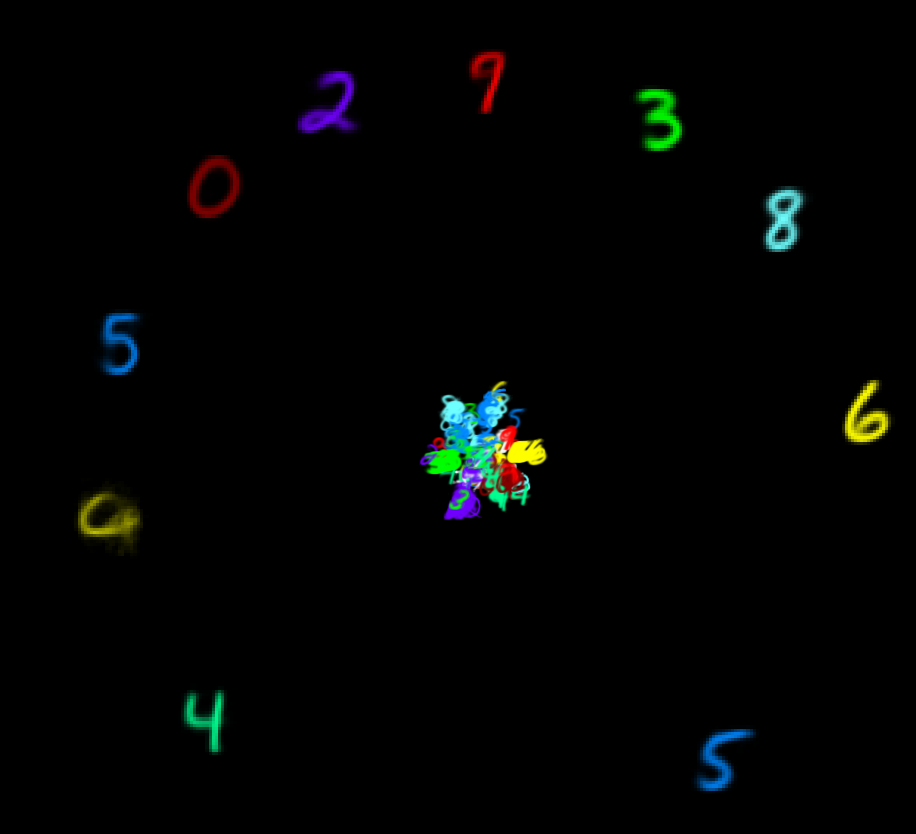

In [ ]:
mnistVisuals.plot_mnist_digits(voltage_map, data_to_save['centroids'], data_to_save['majority_labels'])

In [10]:
def plot_with_landmarks_colored(data_to_save):
    va = data_to_save['voltage_map'].voltage_array()
    centroids = visualHelpers.transform(va, 'mds')
    all_voltages = data_to_save['all_voltages'].entries
    
    # Collect all landmark indices
    landmark_indices = {entry['landmark'].index for entry in all_voltages}

    plt.figure(figsize=(8, 6))
    for i, point in enumerate(centroids):
        if np.max(va[i]) == 1:
            plt.scatter(point[0], point[1], color='yellow', label='Landmark' if i == list(landmark_indices)[0] else "")
        else:
            plt.scatter(point[0], point[1], color='blue', s=10)

    plt.title("Centroid Points with Landmarks Highlighted")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.grid(True)
    plt.show()

/tmp/ipykernel_33882/3270587395.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


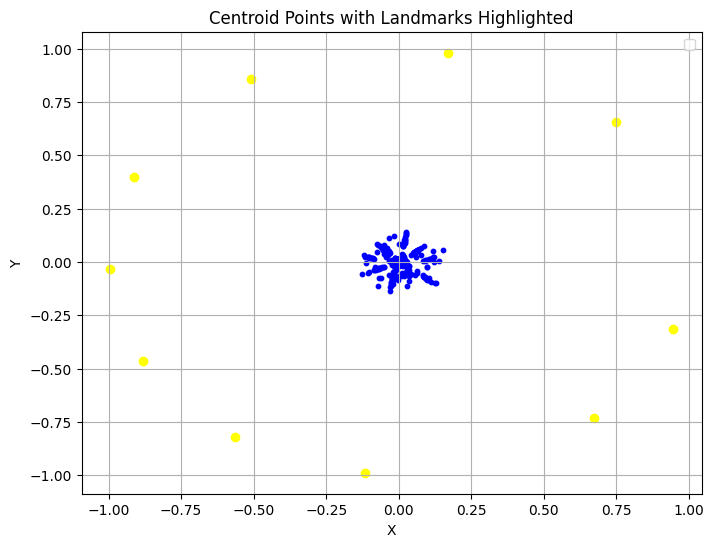

In [11]:
plot_with_landmarks_colored(data_to_save)